Membership

In [97]:
import pandas as pd

# 파일 불러오기
df = pd.read_csv("C:/Users/user/Desktop/기업 연계 데이터/original data/Membership.csv")

# user_no별 등장 횟수 계산
user_counts = df["user_no"].value_counts()

# 1. 고유한 user_no 개수
unique_user_no_count = df["user_no"].nunique()

# 2. 2번 이상 나온 user_no 개수
duplicate_user_no_count = (user_counts >= 2).sum()

# 3. 2번 이상 나온 user_no들의 등장 횟수별 빈도수
duplicate_frequency = user_counts[user_counts >= 2].value_counts().sort_index()

print("고유한 user_no 개수 :", unique_user_no_count)
print("2번 이상 나온 user_no 개수 :", duplicate_user_no_count)

print("\n등장 횟수별 빈도수")
print(duplicate_frequency)


고유한 user_no 개수 : 17845
2번 이상 나온 user_no 개수 : 295

등장 횟수별 빈도수
count
2    269
3     19
4      2
5      2
6      1
7      2
Name: count, dtype: int64


In [98]:
17845 - 295

17550

In [99]:
269 + 19 * 2 + 3 * 2 + 4 * 2 + 5 * 1 + 6 * 2

338

In [100]:
17845 - 338

17507

In [101]:
import pandas as pd

# 파일 경로 지정
file_path = r"C:\Users\user\Desktop\기업 연계 데이터\original data\Membership.csv"

# 파일 불러오기
df = pd.read_csv(file_path)

# user_no별 등장 횟수 계산
user_counts = df["user_no"].value_counts()

# 정확히 4번 등장한 user_no 추출
user_no_4_times = user_counts[user_counts == 4].index

# 해당 행만 추출
df_4_times = df[df["user_no"].isin(user_no_4_times)].copy()

# user_no 앞 5글자만 보기 위한 컬럼 생성
df_4_times["user_no_5"] = df_4_times["user_no"].astype(str).str[:5]

# 필요한 컬럼만 조회
result = (
    df_4_times[["user_no_5", "billing_method", "amount", "reg_date", "end_date"]]
    .sort_values(["user_no_5", "reg_date"])
)

print(result)


      user_no_5  billing_method    amount    reg_date    end_date
3179      412fe             140      9.99  2021-03-08  2021-03-09
13464     412fe             140     13.49  2021-03-09  2021-03-09
14252     412fe             140     16.49  2021-03-09  2021-03-09
9554      412fe             131   7900.00  2021-03-11  2021-03-11
6178      6bd93             131  13900.00  2021-03-04  2021-03-04
14267     6bd93             131   7900.00  2021-03-04  2021-03-04
8252      6bd93             170   7900.00  2021-03-05  2021-03-05
15913     6bd93             151   7900.00  2021-03-05  2021-03-05


User_Mapping

In [102]:
import pandas as pd

# 파일 경로 지정
file_path = r"C:\Users\user\Desktop\기업 연계 데이터\original data\User_Mapping.csv"

# 파일 불러오기
df = pd.read_csv(file_path)

# Uid별 등장 횟수 계산
uid_counts = df["uid"].value_counts()

# 고유한 Uid 개수
unique_uid_count = df["uid"].nunique()

# 2번 이상 나온 Uid 개수
duplicate_uid_count = (uid_counts >= 2).sum()

# 2번 이상 나온 uid의 등장 횟수별 빈도수
duplicate_frequency = uid_counts[uid_counts >= 2].value_counts().sort_index()

print("고유한 uid 개수 :", unique_uid_count)
print("2번 이상 나온 uid 개수 :", duplicate_uid_count)

print("\n등장 횟수별 빈도수")
print(duplicate_frequency)


고유한 uid 개수 : 19828
2번 이상 나온 uid 개수 : 48

등장 횟수별 빈도수
count
2    47
3     1
Name: count, dtype: int64


In [103]:
import pandas as pd

# 파일 경로 지정
file_path = r"C:\Users\user\Desktop\기업 연계 데이터\original data\User_Mapping.csv"

# 파일 불러오기
df = pd.read_csv(file_path)

# uid별 등장 횟수 계산
uid_counts = df["uid"].value_counts()

# 정확히 3번 등장한 uid 추출
uid_3_times = uid_counts[uid_counts == 3].index

# 해당 uid의 행만 조회
df_uid_3_times = df[df["uid"].isin(uid_3_times)].sort_values(["uid", "USER_ID"])

# uid와 USER_ID 확인
print(df_uid_3_times[["uid", "USER_ID"]])


                                                     uid  USER_ID
14197  30e3c9509b8d6102f80906a80afcd2a3593d4a69314509...    14197
16265  30e3c9509b8d6102f80906a80afcd2a3593d4a69314509...    16265
18866  30e3c9509b8d6102f80906a80afcd2a3593d4a69314509...    18866


In [104]:
import pandas as pd

# 파일 불러오기
membership_path = r"C:\Users\user\Desktop\기업 연계 데이터\original data\Membership.csv"
user_mapping_path = r"C:\Users\user\Desktop\기업 연계 데이터\original data\User_Mapping.csv"

membership = pd.read_csv(membership_path)
user_mapping = pd.read_csv(user_mapping_path)

# Membership에서 user_no가 2번 이상 등장한 값 추출
membership_counts = membership["user_no"].value_counts()
membership_user_no_2plus = set(membership_counts[membership_counts >= 2].index)

# User_Mapping에서 uid가 2번 이상 등장한 값 추출
user_mapping_counts = user_mapping["uid"].value_counts()
user_mapping_uid_2plus = set(user_mapping_counts[user_mapping_counts >= 2].index)

# User_Mapping의 uid가 Membership의 user_no에 존재하는지 확인
uid_exists_in_membership = user_mapping_uid_2plus & membership_user_no_2plus
uid_not_exists_in_membership = user_mapping_uid_2plus - membership_user_no_2plus

# 결과 출력
print("Membership에서 user_no가 2번 이상 등장한 개수 :", len(membership_user_no_2plus))
print("User_Mapping에서 uid가 2번 이상 등장한 개수 :", len(user_mapping_uid_2plus))
print("둘 다 겹치는 개수 :", len(uid_exists_in_membership))
print("User_Mapping에는 2번 이상 등장하지만 Membership에는 없는 uid 개수 :", len(uid_not_exists_in_membership))


Membership에서 user_no가 2번 이상 등장한 개수 : 295
User_Mapping에서 uid가 2번 이상 등장한 개수 : 48
둘 다 겹치는 개수 : 42
User_Mapping에는 2번 이상 등장하지만 Membership에는 없는 uid 개수 : 6


In [105]:
import pandas as pd

# 파일 불러오기
membership_path = r"C:\Users\user\Desktop\기업 연계 데이터\original data\Membership.csv"
user_mapping_path = r"C:\Users\user\Desktop\기업 연계 데이터\original data\User_Mapping.csv"

membership = pd.read_csv(membership_path)
user_mapping = pd.read_csv(user_mapping_path)

# 등장 횟수 계산
membership_counts = membership["user_no"].value_counts()
user_mapping_counts = user_mapping["uid"].value_counts()

# 각각 2번 이상 등장한 값만 추출
membership_2plus = membership_counts[membership_counts >= 2]
user_mapping_2plus = user_mapping_counts[user_mapping_counts >= 2]

# 둘 다 겹치는 값만 추출
common_ids = set(membership_2plus.index) & set(user_mapping_2plus.index)

# 비교용 데이터프레임 생성
compare_df = pd.DataFrame({
    "id": list(common_ids)
})

compare_df["user_mapping_count"] = compare_df["id"].map(user_mapping_counts)
compare_df["membership_count"] = compare_df["id"].map(membership_counts)
compare_df["same_count_yn"] = compare_df["user_mapping_count"] == compare_df["membership_count"]

# id 제외하고 요약
summary_df = (
    compare_df
    .groupby(["user_mapping_count", "membership_count", "same_count_yn"])
    .size()
    .reset_index(name="freq")
    .sort_values(["user_mapping_count", "membership_count", "same_count_yn"])
)

print(summary_df)


   user_mapping_count  membership_count  same_count_yn  freq
0                   2                 2           True    34
1                   2                 3          False     4
2                   2                 5          False     2
3                   2                 7          False     1
4                   3                 7          False     1


데이터 병합

In [106]:
import pandas as pd

# 파일 불러오기
membership_path = r"C:\Users\user\Desktop\기업 연계 데이터\original data\Membership.csv"
user_mapping_path = r"C:\Users\user\Desktop\기업 연계 데이터\original data\User_Mapping.csv"

membership = pd.read_csv(membership_path)
user_mapping = pd.read_csv(user_mapping_path)

# ID별 등장 횟수 계산
membership_counts = membership["user_no"].value_counts()
user_mapping_counts = user_mapping["uid"].value_counts()

# 공통 ID 추출
common_ids = set(membership_counts.index) & set(user_mapping_counts.index)

# 공통 ID별 등장 횟수 비교 테이블 생성
compare_df = pd.DataFrame({"id": list(common_ids)})
compare_df["membership_count"] = compare_df["id"].map(membership_counts)
compare_df["user_mapping_count"] = compare_df["id"].map(user_mapping_counts)
compare_df["same_count_yn"] = compare_df["membership_count"] == compare_df["user_mapping_count"]

# 1회 등장 공통 ID 추출
single_match_ids = compare_df.loc[
    (compare_df["membership_count"] == 1) &
    (compare_df["user_mapping_count"] == 1),
    "id"
]

# 중복 등장 공통 ID 중 등장 횟수가 같은 ID만 추출
duplicate_match_ids = compare_df.loc[
    (compare_df["membership_count"] >= 2) &
    (compare_df["user_mapping_count"] >= 2) &
    (compare_df["same_count_yn"]),
    "id"
]

# 최종 병합 대상 ID 생성
valid_ids = pd.Index(single_match_ids.tolist() + duplicate_match_ids.tolist())

# 병합 대상만 필터링
membership_valid = membership[membership["user_no"].isin(valid_ids)].copy()
user_mapping_valid = user_mapping[user_mapping["uid"].isin(valid_ids)].copy()

# 같은 ID 안에서 병합 순번 생성
membership_valid["match_order"] = membership_valid.groupby("user_no").cumcount()
user_mapping_valid["match_order"] = user_mapping_valid.groupby("uid").cumcount()

# 1:1 병합
merged_df = user_mapping_valid.merge(
    membership_valid,
    left_on=["uid", "match_order"],
    right_on=["user_no", "match_order"],
    how="inner",
    suffixes=("_um", "_membership")
)

# 결과 요약
print("공통 ID 개수 :", len(compare_df))
print("1회 등장 병합 ID 개수 :", single_match_ids.nunique())
print("중복 등장 병합 ID 개수 :", duplicate_match_ids.nunique())
print("최종 병합 대상 ID 개수 :", valid_ids.nunique())
print("최종 병합 결과 행 개수 :", len(merged_df))


공통 ID 개수 : 17845
1회 등장 병합 ID 개수 : 17550
중복 등장 병합 ID 개수 : 34
최종 병합 대상 ID 개수 : 17584
최종 병합 결과 행 개수 : 17618


In [107]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17618 entries, 0 to 17617
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   uid                 17618 non-null  object 
 1   USER_ID             17618 non-null  int64  
 2   match_order         17618 non-null  int64  
 3   user_no             17618 non-null  object 
 4   product_cd          17618 non-null  object 
 5   amount              17618 non-null  float64
 6   billing_method      17618 non-null  int64  
 7   concurrent_streams  17573 non-null  float64
 8   promotion_yn        9137 non-null   object 
 9   is_churn_prevented  3154 non-null   object 
 10  repurchase          11728 non-null  object 
 11  payment_device      17618 non-null  object 
 12  is_user_verified    17040 non-null  object 
 13  gender              17472 non-null  object 
 14  age                 17472 non-null  float64
 15  reg_date            17618 non-null  object 
 16  reg_

In [108]:
merged_df['match_order'].value_counts()

match_order
0    17584
1       34
Name: count, dtype: int64

In [109]:
# match_order가 0, 1 둘 다 존재하는 user_no 찾기
pair_user_nos = (
    merged_df.loc[merged_df["match_order"].isin([0, 1]), ["user_no", "match_order"]]
    .drop_duplicates()
    .groupby("user_no")["match_order"]
    .nunique()
)

# 0과 1이 모두 있는 user_no 3개 추출
sample_user_nos = pair_user_nos[pair_user_nos == 2].head(5).index

# 해당 user_no들에 대해 match_order 0, 1만 보기
sample_pairs_df = (
    merged_df.loc[
        merged_df["user_no"].isin(sample_user_nos) &
        merged_df["match_order"].isin([0, 1])
    ]
    .sort_values(["user_no", "match_order"])
)

print("선택된 user_no 5개:")
print(list(sample_user_nos))
print("\n총 행 개수:", len(sample_pairs_df))

print(sample_pairs_df)


선택된 user_no 5개:
['0258fd467c5765400d487d203f7c77afb597120daa9b1ede96e6a06122e89ea3120f1c5b6932ce435b954aab5da1999305ab7de84225bd741ee334c26ff1ce33', '03207f956c0a2d363285286b1a9ede62e03373a9242253c7d6d5fb99819d4eb983fc1191e4dda5dd1b15ad690f9f115c47140236a4887ee22e1ab344985982d5', '06413c96660e23ddd8e6cc93b3e03e299201a9a1aa05ba70ea10b8a8c6f7a17686772ce450d9427ac59dd24d830052c31a8122bb355ce6d58ae7d6d16a9c8d65', '072c0b5986c11d3c3e14fcd4f213a2cba2e973e41e635c1d51af7282689df42cb2d43ab52af8869a7780f26cd86e2f5ea384d3fbadca5ca2a72f04f77909084c', '07e8934c2a06f8b6e27296413d04e783282f9446ea0c8c983a99fbfcb6646e34c86e2ba3d365d822d0f6978b8b38a354b089e2caf0ffa9ab3c49df4151f13ac0']

총 행 개수: 10
                                                     uid  USER_ID  \
2999   0258fd467c5765400d487d203f7c77afb597120daa9b1e...     3363   
14426  0258fd467c5765400d487d203f7c77afb597120daa9b1e...    16255   
1344   03207f956c0a2d363285286b1a9ede62e03373a9242253...     1503   
5068   03207f956c0a2d363285286b1a9e

In [110]:
# user_no와 match_order 컬럼 제거 
merged_df = merged_df.drop(columns=["user_no", "match_order"])

In [111]:
import pandas as pd

membership_path = r"C:\Users\user\Desktop\기업 연계 데이터\original data\Membership.csv"
user_mapping_path = r"C:\Users\user\Desktop\기업 연계 데이터\original data\User_Mapping.csv"

membership = pd.read_csv(membership_path)
user_mapping = pd.read_csv(user_mapping_path)

# NaN 제거 후 고유 ID 집합 생성
membership_ids = set(membership["user_no"].dropna().unique())
user_mapping_ids = set(user_mapping["uid"].dropna().unique())

# 공통 및 차집합 확인
common_ids = membership_ids & user_mapping_ids
membership_only_ids = membership_ids - user_mapping_ids
user_mapping_only_ids = user_mapping_ids - membership_ids

print("membership 고유 user_no 개수 :", len(membership_ids))
print("user_mapping 고유 uid 개수 :", len(user_mapping_ids))
print("공통 ID 개수 :", len(common_ids))
print("membership에만 있는 ID 개수 :", len(membership_only_ids))
print("user_mapping에만 있는 ID 개수 :", len(user_mapping_only_ids))

# membership의 모든 user_no가 user_mapping에 존재하는지 확인
print("membership의 모든 user_no가 user_mapping에 존재하는가? :", membership_ids.issubset(user_mapping_ids))


membership 고유 user_no 개수 : 17845
user_mapping 고유 uid 개수 : 19828
공통 ID 개수 : 17845
membership에만 있는 ID 개수 : 0
user_mapping에만 있는 ID 개수 : 1983
membership의 모든 user_no가 user_mapping에 존재하는가? : True


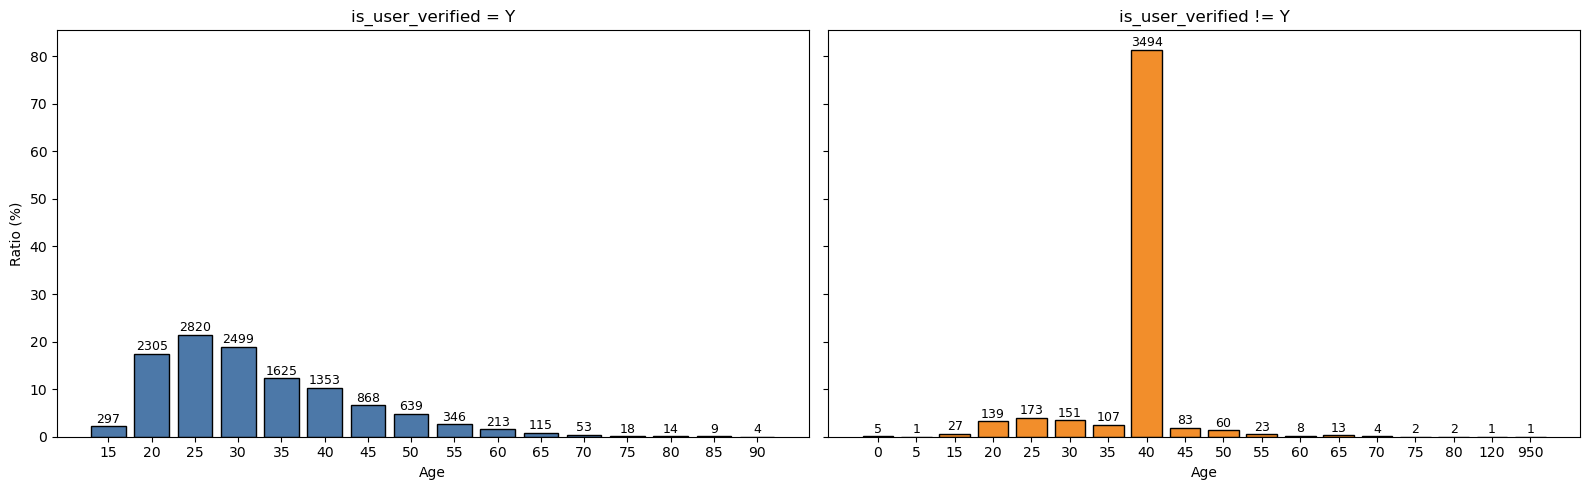

In [112]:
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 준비
verified_age_df = merged_df[["is_user_verified", "age"]].copy()
verified_age_df["age"] = pd.to_numeric(verified_age_df["age"], errors="coerce")
verified_age_df = verified_age_df.dropna(subset=["age"])

# 그룹 구분
verified_age_df["verified_group"] = verified_age_df["is_user_verified"].apply(
    lambda x: "Y" if x == "Y" else "Other"
)

# 그룹별 age 건수 집계
age_count_df = (
    verified_age_df
    .groupby(["verified_group", "age"])
    .size()
    .reset_index(name="count")
)

# 그룹별 age 비율 계산
age_count_df["ratio_pct"] = (
    age_count_df.groupby("verified_group")["count"]
    .transform(lambda x: x / x.sum() * 100)
)

# 그룹별 데이터 분리
y_df = age_count_df[age_count_df["verified_group"] == "Y"].sort_values("age")
other_df = age_count_df[age_count_df["verified_group"] == "Other"].sort_values("age")

# 그래프 생성
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# Y 그룹 그래프
axes[0].bar(
    y_df["age"].astype(int).astype(str),
    y_df["ratio_pct"],
    color="#4C78A8",
    edgecolor="black"
)
axes[0].set_title("is_user_verified = Y")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Ratio (%)")

for _, row in y_df.iterrows():
    axes[0].text(
        x=str(int(row["age"])),
        y=row["ratio_pct"] + 0.1,
        s=str(int(row["count"])),
        ha="center",
        va="bottom",
        fontsize=9
    )

# Other 그룹 그래프
axes[1].bar(
    other_df["age"].astype(int).astype(str),
    other_df["ratio_pct"],
    color="#F28E2B",
    edgecolor="black"
)
axes[1].set_title("is_user_verified != Y")
axes[1].set_xlabel("Age")

for _, row in other_df.iterrows():
    axes[1].text(
        x=str(int(row["age"])),
        y=row["ratio_pct"] + 0.1,
        s=str(int(row["count"])),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


View_History

In [113]:
import pandas as pd

# CSV 파일 경로 설정
file_path = r"C:\Users\user\Desktop\기업 연계 데이터\original data\View_History.csv"

# 데이터프레임 불러오기
df = pd.read_csv(file_path)

# 고유값 개수 확인
print("고유 USER_ID 개수:", df["USER_ID"].nunique())
print("고유 MOVIE_ID 개수:", df["MOVIE_ID"].nunique())


고유 USER_ID 개수: 14892
고유 MOVIE_ID 개수: 5196


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106205 entries, 0 to 106204
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   USER_ID    106205 non-null  int64
 1   MOVIE_ID   106205 non-null  int64
 2   DURATION   106205 non-null  int64
 3   WATCH_DAY  106205 non-null  int64
 4   WATCH_SEQ  106205 non-null  int64
dtypes: int64(5)
memory usage: 4.1 MB


In [115]:
common_user_ids = set(merged_df["USER_ID"].dropna()) & set(df["USER_ID"].dropna())

print("같은 USER_ID 개수:", len(common_user_ids))


같은 USER_ID 개수: 14675


In [116]:
merged_user_ids = set(merged_df["USER_ID"].dropna())
df_user_ids = set(df["USER_ID"].dropna())

only_in_merged = merged_user_ids - df_user_ids
only_in_df = df_user_ids - merged_user_ids

print("merged_df에만 있는 USER_ID 개수:", len(only_in_merged))
print("df에만 있는 USER_ID 개수:", len(only_in_df))


merged_df에만 있는 USER_ID 개수: 2943
df에만 있는 USER_ID 개수: 217


In [117]:
import pandas as pd

merged_result = pd.merge(
    df,
    merged_df,
    on="USER_ID",
    how="inner"
)

merged_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104619 entries, 0 to 104618
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   USER_ID             104619 non-null  int64  
 1   MOVIE_ID            104619 non-null  int64  
 2   DURATION            104619 non-null  int64  
 3   WATCH_DAY           104619 non-null  int64  
 4   WATCH_SEQ           104619 non-null  int64  
 5   uid                 104619 non-null  object 
 6   product_cd          104619 non-null  object 
 7   amount              104619 non-null  float64
 8   billing_method      104619 non-null  int64  
 9   concurrent_streams  104264 non-null  float64
 10  promotion_yn        54572 non-null   object 
 11  is_churn_prevented  19093 non-null   object 
 12  repurchase          69052 non-null   object 
 13  payment_device      104619 non-null  object 
 14  is_user_verified    101388 non-null  object 
 15  gender              103879 non-nul

In [118]:
print("고유 USER_ID 개수:", merged_result["USER_ID"].nunique())
print("고유 MOVIE_ID 개수:", merged_result["MOVIE_ID"].nunique())
print("고유 uid 개수:", merged_result["uid"].nunique())

고유 USER_ID 개수: 14675
고유 MOVIE_ID 개수: 5171
고유 uid 개수: 14645


In [119]:
uid_user_count = (
    merged_result.dropna(subset=["uid", "USER_ID"])
    .groupby("uid")["USER_ID"]
    .nunique()
)

uid_user_count_summary = (
    uid_user_count
    .value_counts()
    .sort_index()
    .rename_axis("USER_ID개수")
    .reset_index(name="빈도")
)

print(uid_user_count_summary)


   USER_ID개수     빈도
0          1  14615
1          2     30


Movie_Master

In [120]:
import pandas as pd

# CSV 파일 경로 설정
file_path = r"C:\Users\user\Desktop\기업 연계 데이터\original data\Movie_Master.csv"

# 데이터프레임 불러오기
df = pd.read_csv(file_path)

# 고유 MOVIE_ID 개수 확인
print("고유 MOVIE_ID 개수:", df["MOVIE_ID"].nunique())


고유 MOVIE_ID 개수: 14018


In [121]:
merged_movie_ids = set(merged_result["MOVIE_ID"].dropna())
df_movie_ids = set(df["MOVIE_ID"].dropna())

common_movie_ids = merged_movie_ids & df_movie_ids
only_in_merged_result = merged_movie_ids - df_movie_ids
only_in_df = df_movie_ids - merged_movie_ids

print("공통으로 존재하는 MOVIE_ID 개수:", len(common_movie_ids))
print("merged_result에만 있는 MOVIE_ID 개수:", len(only_in_merged_result))
print("df에만 있는 MOVIE_ID 개수:", len(only_in_df))


공통으로 존재하는 MOVIE_ID 개수: 5171
merged_result에만 있는 MOVIE_ID 개수: 0
df에만 있는 MOVIE_ID 개수: 8847


In [122]:
final_merged = pd.merge(
    merged_result,
    df,
    on="MOVIE_ID",
    how="inner",
    suffixes=("_merged_result", "_df")
)

final_merged.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104619 entries, 0 to 104618
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   USER_ID             104619 non-null  int64  
 1   MOVIE_ID            104619 non-null  int64  
 2   DURATION            104619 non-null  int64  
 3   WATCH_DAY           104619 non-null  int64  
 4   WATCH_SEQ           104619 non-null  int64  
 5   uid                 104619 non-null  object 
 6   product_cd          104619 non-null  object 
 7   amount              104619 non-null  float64
 8   billing_method      104619 non-null  int64  
 9   concurrent_streams  104264 non-null  float64
 10  promotion_yn        54572 non-null   object 
 11  is_churn_prevented  19093 non-null   object 
 12  repurchase          69052 non-null   object 
 13  payment_device      104619 non-null  object 
 14  is_user_verified    101388 non-null  object 
 15  gender              103879 non-nul

In [123]:
uid_user_count = (
    final_merged.dropna(subset=["uid", "USER_ID"])
    .groupby("uid")["USER_ID"]
    .nunique()
)

uid_user_count_summary = (
    uid_user_count
    .value_counts()
    .sort_index()
    .rename_axis("USER_ID개수")
    .reset_index(name="빈도")
)

print(uid_user_count_summary)


print("고유 USER_ID 개수:", final_merged["USER_ID"].nunique())
print("고유 uid 개수:", final_merged["uid"].nunique())
print("고유 MOVIE_ID 개수:", final_merged["MOVIE_ID"].nunique())


   USER_ID개수     빈도
0          1  14615
1          2     30
고유 USER_ID 개수: 14675
고유 uid 개수: 14645
고유 MOVIE_ID 개수: 5171


저장

In [124]:
import sqlite3

# 저장 경로 설정
csv_path = r"C:\Users\user\Desktop\기업 연계 데이터\data merge\final_merged.csv"
db_path = r"C:\Users\user\Desktop\기업 연계 데이터\data merge\final_merged.db"

# DB 테이블명 설정
table_name = "final_merged"

# CSV 저장
final_merged.to_csv(csv_path, index=False, encoding="utf-8-sig")

# DB 저장
with sqlite3.connect(db_path) as conn:
    final_merged.to_sql(table_name, conn, if_exists="replace", index=False)

print("CSV 저장 완료:", csv_path)
print("DB 저장 완료:", db_path)
print("DB 테이블명:", table_name)


CSV 저장 완료: C:\Users\user\Desktop\기업 연계 데이터\data merge\final_merged.csv
DB 저장 완료: C:\Users\user\Desktop\기업 연계 데이터\data merge\final_merged.db
DB 테이블명: final_merged


In [125]:
# 총 줄어든 행 개수 
106205 - 104619

1586

In [126]:
import pandas as pd

csv_path = r"C:\Users\user\Desktop\기업 연계 데이터\data merge\final_merged.csv"
file_path = r"C:\Users\user\Desktop\기업 연계 데이터\data merge\final_merged.csv"

# CSV 파일 불러오기
df = pd.read_csv(file_path, low_memory=False)

# 필요한 컬럼만 선택
df = df[["uid", "USER_ID", "repurchase", "reg_date", "end_date"]].copy()

# uid, USER_ID 결측치 제거
df = df[df["uid"].notna() & df["USER_ID"].notna()].copy()

# 문자열 형변환
df["uid"] = df["uid"].astype(str)
df["USER_ID"] = df["USER_ID"].astype(str)

# 날짜 정렬용 변환
df["reg_date_dt"] = pd.to_datetime(df["reg_date"], errors="coerce")
df["end_date_dt"] = pd.to_datetime(df["end_date"], errors="coerce")

# uid별 고유 USER_ID 개수 계산
uid_userid_counts = df.groupby("uid")["USER_ID"].nunique()

# 고유 USER_ID를 2개 이상 보유한 uid 추출
target_uids = uid_userid_counts[uid_userid_counts >= 2].index

# 조건을 만족하는 고유 uid 개수 출력
print(f"고유 USER_ID를 2개 이상 보유한 고유 uid 개수: {len(target_uids)}")

# 대상 uid만 필터링
result = df[df["uid"].isin(target_uids)].copy()

# 같은 uid 내에서 같은 USER_ID는 1행만 남기기 위한 정렬
result = result.sort_values(
    by=["uid", "USER_ID", "reg_date_dt", "end_date_dt"],
    na_position="last"
)

# uid + USER_ID별 1행만 유지
result = result.drop_duplicates(subset=["uid", "USER_ID"], keep="first").copy()

# 출력용 uid 5글자 생성
result["uid_5"] = result["uid"].str[:5]

# 최종 출력 컬럼 정리
result = result[["uid_5", "USER_ID", "repurchase", "reg_date", "end_date"]].reset_index(drop=True)

# 결과 출력
print(result.to_string(index=False))


고유 USER_ID를 2개 이상 보유한 고유 uid 개수: 30
uid_5 USER_ID repurchase   reg_date   end_date
0258f   16255        NaN 2021-03-12 2021-03-12
0258f    3363        NaN 2021-03-11 2021-04-12
03207    1503        NaN 2021-03-13 2021-03-13
03207    5706          O 2021-03-13 2021-04-13
06413   13820        NaN 2021-03-06 2021-03-12
06413   17661        NaN 2021-03-12 2021-04-12
072c0   10426        NaN 2021-03-09 2021-03-09
072c0   15041        NaN 2021-03-09 2021-04-10
07e89    1781          O 2021-03-13 2021-04-13
07e89    3216        NaN 2021-03-13 2021-03-13
12688   11798          O 2021-03-01 2021-04-01
12688   17224        NaN 2021-03-01 2021-03-01
1f683   14569        NaN 2021-03-13 2021-04-14
1f683    3867          O 2021-03-11 2021-04-11
30b52   11186        NaN 2021-03-04 2021-04-04
30b52   18163        NaN 2021-03-14 2021-03-14
48a19   17460          O 2021-03-12 2021-04-12
48a19     946        NaN 2021-03-12 2021-03-12
51114   18438        NaN 2021-03-01 2021-03-01
51114    9048        NaN